# Video Games Data Science Analysis

## Objective
The objective is to analyze the factors that influence video games success, by combining two independent datasets and applying data science techniques, which I have learned
in 'Data Science' course from SoftUni. Suche techniques are such as data cleaning, 
exploratory data analysis, statistical analysis, and data merging.

## Datasets
- `Video_Games_Sales_as_at_22_Dec_2016.csv` – primary dataset used to measure success through global sales
- `games.csv` – secondary dataset is used to enrich the analysis with additional data.

## Methodology
The project will follow a structured workflow:
#### 1. Load and inspect the datasets.
#### 2. Identify quality issues of the data.
#### 3. Clean and prepare the data.
#### 4. Merge relevant info from both sources.
#### 5. Explore relationships between the variables.
#### 6. Interpret findings and draw conclusions.
#### 7. Data visualization (histograms).
#### 8. Text-related analysis (using available text).
#### 9. Image-related exploration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sales_dataset = pd.read_csv("../data/Video_Games_Sales_as_at_22_Dec_2016.csv")
steam_dataset = pd.read_csv("../data/games.csv")

## Initial Data Inspection

Тhe goal in this section, is to perform an initial inspection of both datasets.This will help to understand their structure, content, and overall quality.

The following steps are performed:
- Previewing the first rows of each dataset in order to get a quick overview;
- Examine the structure of the datasets, including: column names, data types, number of non-null values

This step helps identify:
- missing values;
- potential data type issues and problems;
- relevant columns;
- possibilities for later merge of the datasets.

In [ ]:
sales_dataset.head()
steam_dataset.head()

sales_dataset.info()
steam_dataset.info()

## Observations from the Initial Inspection

### Sales Dataset
The sales dataset is well-structured and contains key variables related to game performance, such as `Global_Sales`, which will be used as the main indicator of success.

However, several issues are observed:
- Missing values in `Year_of_Release` and `Publisher`;
- Significant missing data in `Critic_Score`, `User_Score`, and related columns;
- Some categorical fields like `Developer`, `Rating` are incomplete.

---

### Steam Dataset
The Steam dataset contains a much larger number of cols and provides more data, including:
- gameplay information (playtime, achievements)
- user feedback proxies (`Positive`, `Negative`, `User score`)
- textual data (`About the game`, `Reviews`)
- categorical data (`Genres`, `Categories`, `Tags`)

This dataset is noisier:
- Many columns are containing missing values;
- The data is less structured compared to the sales dataset

---

### Key Observations for the Project
- Both datasets contain a `Name` column, which can be used for later merging;
- The datasets are different in structure and purpose:
  - the sales dataset focuses more on performance (target variable);
  - the Steam dataset provides explanatory features;
- It requires careful data cleaning before merging

---

### Next Step
The next step is to analyze the missing values in more depth and determine how they should be handled.

## Missing Values in the Sales Dataset

The goal is to identify and missing values.

The step includes:
- counting missing values.
- calculating the percentage of missing values based on the dataset size.

This helps determine:
- which columns are reliable and may require cleaning, transformation or needed to be removed.

In [ ]:
sales_dataset.isnull().sum()
(sales_dataset.isnull().sum() / len(sales_dataset)) * 100

## Observations from Missing Values in sales dataset

### Low Missing Data (Safe to Use)
The following columns contain little missing data and can be used in the analysis:
- `Platform`, `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, `Global_Sales`

Columns like 
- `Name`, `Genre`, `Publisher` also have very few missing values.
---

### Moderate Missing Data
- `Year_of_Release` has around 1.6% missing values
- `Publisher` has around 0.3% missing values

    These columns are usable and missing values can be handled with strategies like removal or imputation.
---

### High Missing Data
Several columns contain a significant amount of missing data:
- `Critic_Score` and `Critic_Count` -> around 51%
- `User_Score` and `User_Count` -> around 54%
- `Developer` -> around 39%
- `Rating` -> around 40%

    These columns may require special handling:
    - they cannot be used directly without cleaning
---

### Key Takeaways
- The core performance data (`Global_Sales`) is reliable.
- Some metadata columns are partially missing but are also still usable.
- Review-related features have significant missing data and must be treated carefully.
---

### Next Step
The next step is to perform the same missing values analysis on the Steam dataset.

## Missing Values in Steam Dataset

The goal is to analyze the missing values.

Due to the larger size and complexity of this dataset, this step is essential to:
- identify unreliable columns.
- detect noisy or irrelevant data.
- determine which features can be used in the analysis.

The analysis also includes both absolute and in percentage evaluation of missing values.

In [ ]:
steam_dataset.isnull().sum()
(steam_dataset.isnull().sum() / len(steam_dataset)) * 100

## Observations from Missing Values in Steam Dataset

### Low Missing Data (Reliable Columns)
Several columns contain little or no missing values and can be safely used:
- `Name`, `Release date`, `Price`, `Peak CCU`, `Positive`,
- `Negative`, `User score`, `Achievements`, `Recommendations`
- playtime-related features

These columns are strong candidates for further analysis.
---

### Moderate Missing Data
The following columns contain a manageable amount of missing values:
- `Developers`, `Publishers`, `Genres`, `Categories`,
- `Tags`, `Screenshots`, `Movies`

These can still be used after light cleaning.
---

### High Missing Data (Problematic / Likely to Drop)
These columns contain high levels of missing data:
- `Reviews` -> around 87%
- `Metacritic url` -> around 94%
- `Score rank` -> around 99%
- `Notes` -> around 85%

These columns are not reliable and will likely be excluded from the analysis.
---

### Medium-High Missing (Context-dependent)
- `Website`, `Support url`, `Support email`

These are not analytically useful and can be removed.
---

### Key Takeaways
- The dataset contains many useful behavioral and engagement features.
- Several columns are metadata or contain a lot of missing values.
- Careful feature selection will be required before merging and analysis.
---

### Next Step
The next step is to define a data cleaning strategy and decide which columns to keep, transform, or remove.

In [ ]:
sales_dataset["User_Score"].unique()
sales_dataset["Year_of_Release"].unique()
sales_dataset.duplicated().sum()

steam_dataset.duplicated().sum()
set(sales_dataset["Name"]).intersection(set(steam_dataset["Name"]))
len(set(sales_dataset["Name"]).intersection(set(steam_dataset["Name"])))

## Data Cleaning and Merge Posibility

Before proceeding with merging the datasets, it is important to evaluate whether is possible to do it.
Since both datasets contain a `Name` column, it is used as a potential key for matching records.
To assess compatibility, the intersection between the game names in both datasets was calculated.
---

### Matching Results

The analysis shows that there are **586 matching game titles** between the two datasets.
---

### Interpretation

The limited number of matches is expected due to several factors:
- the sales dataset contains many console games that are older.
- the Steam dataset focuses primarily on the PC games.
- naming inconsistencies may exist between datasets.
---

### Conclusion

Although the overlap is limited, it is possiblr to perform a combined analysis on a subset of games.

This subset will be used for merging the datasets and exploring relationships between:
- game success (Global_Sales)
- gameplay and engagement features from Steam
---

### Next Step

The next step is to prepare the datasets for merging by selecting relevant columns and cleaning the data where necessary.

## Data Cleaning and Preparation

Before merging the two datasets, it is necessary to prepare them.
This block performs the following steps:

- Review the available columns in both datasets.
- Select only the most relevant variables.
- Create reduced versions of the datasets containing the selected columns.
- Convert the Steam release date column to a proper datetime format.
- Extract the release year from the Steam release date.
- Standardize the `Name` column in both datasets by converting values to lowercase and removing the extra spaces.
- Merge the datasets using the game title as key.

In [ ]:
sales_dataset.columns
selected_sales_columns = [
    "Name",
    "Platform",
    "Year_of_Release",
    "Genre",
    "Global_Sales",
    "Critic_Score",
    "User_Score"
]

sales_cleaned = sales_dataset[selected_sales_columns]
sales_cleaned.head()


steam_dataset.columns
selected_steam_columns = [
    "Name",
    "Release date",
    "Price",
    "Peak CCU",
    "User score",
    "Positive",
    "Negative",
    "Achievements",
    "Recommendations",
    "Average playtime forever",
    "Developers",
    "Publishers",
    "Categories",
    "Genres",
    "Tags"
]

steam_cleaned = steam_dataset[selected_steam_columns]
steam_cleaned.head()

steam_cleaned["Release date"] = pd.to_datetime(
    steam_cleaned["Release date"],
    errors="coerce"
)
steam_cleaned["Release date"].head()

steam_cleaned["Release_Year"] = steam_cleaned["Release date"].dt.year
steam_cleaned[["Name", "Release date", "Release_Year"]].head()

sales_cleaned["Name"] = sales_cleaned["Name"].str.lower().str.strip()
steam_cleaned["Name"] = steam_cleaned["Name"].str.lower().str.strip()

sales_cleaned["Name"].head()


merged_dataset = pd.merge(
    sales_cleaned,
    steam_cleaned,
    on="Name",
    how="inner"
)

merged_dataset.head()
len(merged_dataset)

1276

## Observations from Data Cleaning and Preparation

The data preparation process was completed successfully.

### Column Selection
Both datasets contained many columns, but only the most relevant were kept.  
This helped reduce unnecessary complexity.

### Date Transformation
The `Release date` column in the Steam dataset was successfully converted to datetime format, and a new `Release_Year` column was created.  
This makes the Steam data easier to compare with the `Year_of_Release` column from the sales dataset.

### Name Standardization
The `Name` column in both datasets was standardized by converting all values to lowercase and removing the extra spaces between.  
This improves matching consistency in merging.

### Merge Result
The datasets were merged successfully using an inner join on the `Name` column.  
The Merged dataset result contains **1276 rows**.

Some games apperar multiple times and thats because the number is higher.
As a result, one game from the Steam dataset may match several platform records from the sales dataset.

### Conclusion
The merged dataset is now ready for the next phase of the project: exploratory data analysis and investigation of relationships between variables.

## Exploratory Data Analysis – Global Sales

In this section, the goal is to explore the distribution of the main target variable: `Global_Sales`.
This variable represents the overall success of a video game and will be used as the primary metric.

Descriptive statistics are used to understand:
- the central tendency (mean, median)
- the spread of the data (standard deviation)
- the distribution of values (min, max, quartiles)

In [32]:
merged_dataset["Global_Sales"].describe()

count    1276.000000
mean        0.537790
std         1.265983
min         0.010000
25%         0.050000
50%         0.140000
75%         0.470000
max        21.040000
Name: Global_Sales, dtype: float64

## Observations on Global Sales

Statistics reveal several important insights:

- The average global sales are very low (around 0.54), indicating that most games has low commercial success.
- The median value (around 0.14) is also very lower than the mean, suggesting a right-skewed distribution.
- The maximum value (21.04) is much higher than the average, showing that a small number of games achieve extremely high sales.
- The majority of games are with low sales range (below 0.5), as indicated by the quartiles.

### Interpretation

The distribution of `Global_Sales` is highly skewed:
- most games perform poorly or moderately.
- a small number of games are major hits.

### Conclusion

Further analysis will focus on identifying the factors that contribute to higher sales, particularly:
- genre
- user and critic scores
- engagement metrics from the Steam dataset

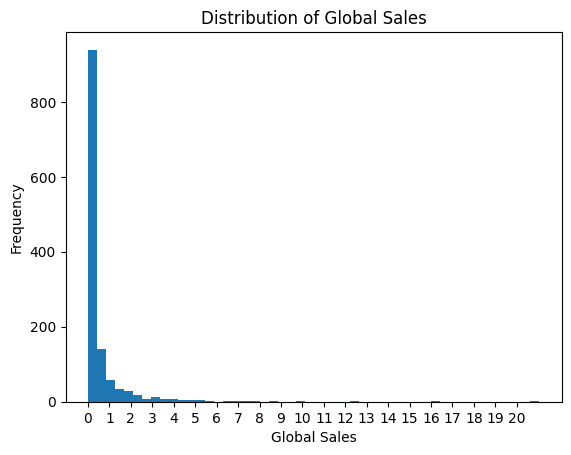

In [37]:
plt.hist(merged_dataset["Global_Sales"], bins=50)
plt.xticks(range(0, 21, 1))
plt.title("Distribution of Global Sales")
plt.xlabel("Global Sales")
plt.ylabel("Frequency")
plt.show()

## Distribution of Global Sales (Histogram)

The histogram clearly shows that the distribution of `Global_Sales` is heavily right-skewed.

### Observations
- The majority of games are very close to zero in sales.
- There is a sharp peak in the lowest range (0–1).
- A long tail extends to the right, representing a small number of highly successful games.
- Very few games exceed even moderate sales values.

### Interpretation

This confirms the earlier statistical findings:
- most games have very low commercial success.
- only a small number of games achieve a very high sales.

### Conclusion

Because of this skewness:
- using only the mean can be misleading.
- the median and distribution shape are more informative.
- further analysis should consider grouping or transforming the data when necessary.

## Correlation Analysis

In this section, the goal is to examine the relationships between the main variables:
- `Global_Sales` (target variable)
- `Critic_Score`
- `User_Score`

    A correlation matrix is used to measure strength and direction of relationships between the current variables.
    This helps identify whether higher scores are associated with higher sales.

In [39]:
merged_dataset[["Global_Sales", "Critic_Score", "User_Score"]].corr()

,Global_Sales,Critic_Score,User_Score
Global_Sales,1.000000,0.364451,0.139998
Critic_Score,0.364451,1.000000,0.622446
User_Score,0.139998,0.622446,1.000000


## Observations from Correlation Analysis

The matrix reveals the following relationships:

### Global Sales vs Critic Score
- Correlation around **0.36**
- This indicates a **moderate positive relationship**
- Games with higher critic scores are tend to have higher sales, but the relationship is not that strong.
---

### Global Sales vs User Score
- Correlation around **0.14**
- This indicates a **weak positive relationship**
- User scores appear to have a limited impact on sales.
---

### Critic Score vs User Score
- Correlation around **0.62**
- This is a **moderately strong positive relationship**
- Critics and users generally agree on game quality, but is not so perfectly.
---

### Interpretation
- Critic scores seem to be more relevant to commercial success than user scores.
- User perception does not strongly translate into the higher sales.
---

### Conclusion
While there is some relationship between scores and sales, it is not strong enough to fully explain the success of a game.  
Further analysis is required to explore additional influencing factors.

## Global Sales by Genre

The goal is to analyze how game genre affects commercial success.

The average `Global_Sales` is calculated for each genre in order to identify:
- which genres tend to perform better commercially and wether a certain type of games are more successful than others.

In [40]:
merged_dataset.groupby("Genre")["Global_Sales"].mean().sort_values(ascending=False)

Genre
Role-Playing    0.845797
Action          0.793429
Misc            0.729600
Shooter         0.602308
Fighting        0.511316
Racing          0.431081
Sports          0.407353
Platform        0.345200
Adventure       0.212086
Strategy        0.183839
Simulation      0.163182
Puzzle          0.104167
Name: Global_Sales, dtype: float64

## Observations on Genre and Sales

The analysis reveals a clear differences in average sales across genres.

### Top Performing Genres
- `Role-Playing` (around 0.85)
- `Action` (around 0.79)
- `Misc` (around 0.73)
- `Shooter` (around 0.60)

These are tend to generate higher average sales than to others.
---

### Mid-range Genres
- `Fighting`, `Racing`, `Sports`, `Platform`

These genres show moderate performance but are also less successful than the top group.
---

### Lower Performing Genres
- `Adventure`, `Strategy`, `Simulation`, `Puzzle`

These genres have lower average sales, indicating lower commercial performance on average.
---

### Interpretation

- Genre plays a significant role in game success.
- Action-oriented and immersive genres (like Action) tend to perform better.
---

### Conclusion

Genre is an important factor influencing video game success, but it does not act alone.